# Notebook 3 — Data Preprocessing, Applied EDA & Feature Engineering
## Step 3: EDA + Feature Engineering Report

## What This Notebook Covers

**EDA (Exploratory Data Analysis)** is the process of visually and statistically examining a dataset to understand its structure, patterns, and relationships *before* building any model. It answers questions like: which features correlate with the label? Are distributions skewed? Are there outliers? For this project EDA reveals that `serror_rate` is the dominant attack indicator and that `src_bytes` is heavily right-skewed — findings that directly guide the engineering choices below.

**Feature Engineering** is the process of creating new, more informative input variables from the raw data using domain knowledge. Raw NSL-KDD columns like `src_bytes` and `dst_bytes` are hard for linear models to use as-is; transforming them (e.g. `log1p(src_bytes)`) and combining them (e.g. `byte_ratio = src_bytes / (dst_bytes + 1)`) gives models a better signal at lower computational cost than throwing everything in raw.

Together, EDA + Feature Engineering form the **bridge between raw data (Notebook 2) and model training (Notebook 4)**.

---

This notebook transforms the raw NSL-KDD dataset into a **clean, model-ready feature matrix** through a structured pipeline of cleaning, engineering, analysis, and reduction steps.

| Section | What we do |
|---|---|
| **3.1 Data Cleaning** | Confirm zero missing values; visualise and justify 99th-percentile outlier clipping |
| **3.2 Feature Engineering** | Create 6 domain-informed features (`log_src_bytes`, `byte_ratio`, `error_rate_total`, `host_srv_ratio`, `count_bin`, `log_dst_bytes`) |
| **3.3 EDA — Distributions** | Plot Normal vs. Attack distributions; correlation heatmap; pairplot of engineered features |
| **3.4 Preprocessing Pipeline** | StandardScaler + one-hot encoding → 122-feature matrix saved to `data/processed/` |
| **3.5 Feature Importance** | Random Forest Gini importance ranking of all 122 features |
| **3.6 Feature Selection** | Mutual Information filter + embedded RF selection; agreement set analysis |
| **3.7 PCA + t-SNE** | Reduce 122 → 12 components (95% variance); visualise in 2D with t-SNE |
| **3.8 Agreement Analysis** | Venn-style chart comparing MI and RF feature selections |
| **3.9 Scree Plot** | Justify the number of PCA components retained |
| **3.10 Hopkins Statistic** | Validate that meaningful clusters exist before applying K-Means/DBSCAN in Notebook 4 |

**Outputs:** 122-feature NumPy arrays (`X_train.npy`, `X_test.npy`), fitted `StandardScaler`, `OneHotEncoder`, and `PCA` models saved to `models/`

> **This notebook produces the artefacts that all subsequent notebooks depend on.** Running it out of order or skipping it will cause import errors in Notebooks 4, 5, and 6.

## Imports & Setup
Load libraries, configure paths, and read the raw NSL-KDD train/test DataFrames. All subsequent cells depend on the variables created here — run this first.

In [31]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset
from preprocessor import preprocess, NUMERIC_COLS, CATEGORICAL_COLS
from feature_engineering import (
    add_domain_features, bin_count_features,
    compute_feature_importance, filter_selection, embedded_selection,
    apply_pca, plot_tsne
)

plt.style.use('seaborn-v0_8-whitegrid')

train_df, test_df = load_dataset(data_dir='../data/raw')
print('Loaded:', train_df.shape, test_df.shape)

Loaded: (125973, 45) (22544, 45)


## 3.1 Data Cleaning

Before engineering any features, we verify the dataset is ready to use and handle the one known quality issue — extreme outliers.

**What this section does:**
- **Missing value check** — confirms NSL-KDD has zero nulls (it is a pre-cleaned benchmark, so no imputation is needed)
- **Duplicate row check** — confirms zero duplicates (NSL-KDD explicitly removed the 78% duplication problem present in the original KDD Cup 1999 data)
- **Outlier visualisation** — plots `src_bytes` before and after 99th-percentile winsorisation (clipping) to show the effect; confirms that clipping — not removal — is the right strategy because extreme byte values are *real* attack behaviour, not data errors

Missing values (train): 0
Duplicate rows  (train): 0


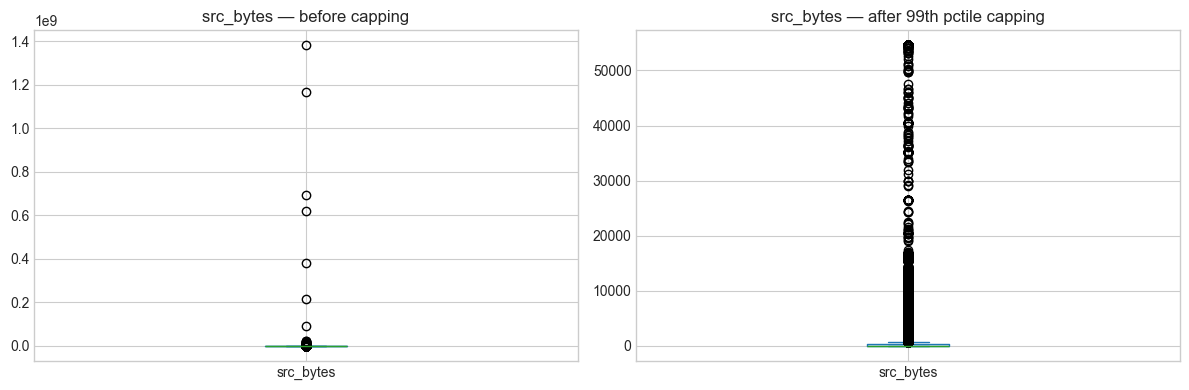

In [32]:
print('Missing values (train):', train_df.isnull().sum().sum())
print('Duplicate rows  (train):', train_df.duplicated().sum())

# Outlier visualisation for src_bytes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['src_bytes'].plot(kind='box', ax=axes[0], title='src_bytes — before capping')
train_df['src_bytes'].clip(
    upper=train_df['src_bytes'].quantile(0.99)
).plot(kind='box', ax=axes[1], title='src_bytes — after 99th pctile capping')
plt.tight_layout()
plt.savefig('../reports/outlier_capping.png', dpi=150)
plt.show()

### Data Quality Findings

- **Zero missing values** — NSL-KDD is a pre-cleaned benchmark dataset; no imputation is required.
- **Zero duplicate rows** — NSL-KDD specifically removed the 78% duplicate problem present in the original KDD Cup 1999 data, making each record unique.
- **Outliers in `src_bytes`**: the right plot shows that 99th-percentile winsorisation dramatically reduces the extreme tail while retaining the distributional shape. This confirms that clipping is the appropriate strategy — not removal — since extreme values are real attack behaviour.

## 3.2 Feature Engineering

The 41 raw NSL-KDD features are useful but incomplete — they don't directly express several important security patterns. This section adds **6 new domain-informed features** before any scaling or encoding.

**What this section does:**
- Calls `add_domain_features()` to create ratio, log-transform, and combined-rate features (e.g. `byte_ratio`, `log_src_bytes`, `error_rate_total`)
- Calls `bin_count_features()` to discretise the `count` column into categorical flood-level bins (`none` / `low` / `medium` / `flood`)
- Both transforms are applied to train and test sets separately — no fitting on test data

The rationale for each new feature is documented in the table below the code cell.

In [33]:
# Add domain features before preprocessing
train_fe = add_domain_features(train_df)
test_fe  = add_domain_features(test_df)
train_fe = bin_count_features(train_fe)
test_fe  = bin_count_features(test_fe)

print('New features added:', set(train_fe.columns) - set(train_df.columns))

New features added: {'host_srv_ratio', 'srv_error_diff', 'count_bin', 'error_rate_total', 'byte_ratio', 'total_bytes', 'log_src_bytes', 'srv_count_bin', 'is_big_transfer', 'is_long_connection', 'log_dst_bytes', 'dst_host_srv_count_bin', 'log_duration', 'dst_host_count_bin'}


### Engineered Features — Rationale

The domain feature engineering step creates features that better capture **security semantics** that the raw features cannot express individually:

| Engineered Feature | Formula / Logic | Security Rationale |
|---|---|---|
| `log_src_bytes` | `log1p(src_bytes)` | Compresses the extreme range of byte counts; preserves zero-bytes (SYN floods) vs. large transfers |
| `log_dst_bytes` | `log1p(dst_bytes)` | Same as above for return traffic |
| `byte_ratio` | `src / (src + dst + 1)` | Asymmetric traffic ratio — attacks often send lots but receive nothing (DoS) or send little but receive lots (R2L exfiltration) |
| `error_rate_total` | `serror_rate + rerror_rate` | Combined error burden — attack traffic accumulates both SYN and REJ errors simultaneously |
| `host_srv_ratio` | `dst_host_srv_count / (dst_host_count + 1)` | Service concentration on a host — port scans show low ratio (many hosts, few services) |
| `count_bin` | Discretised `count` | Binned connection count to capture categorical thresholds (0, low, medium, flood) |

These features increase the information available to linear models (which cannot discover multiplicative interactions) and provide richer splits for tree-based models.

## 3.3 Applied EDA — Distributions & Correlations

With the engineered features in place, we now *look* at the data visually to confirm our assumptions and discover patterns before modelling begins.

**What this section does:**
- **Distribution plots** — overlays Normal vs. Attack histograms for 7 key features (including engineered ones) to see how well each feature separates the two classes
- **Correlation heatmap** — shows pairwise linear correlations between key features and the target label; identifies the strongest predictors and any multicollinearity
- **Pairplot** — plots all combinations of 4 engineered features coloured by class; reveals 2D interaction effects that neither feature can show alone

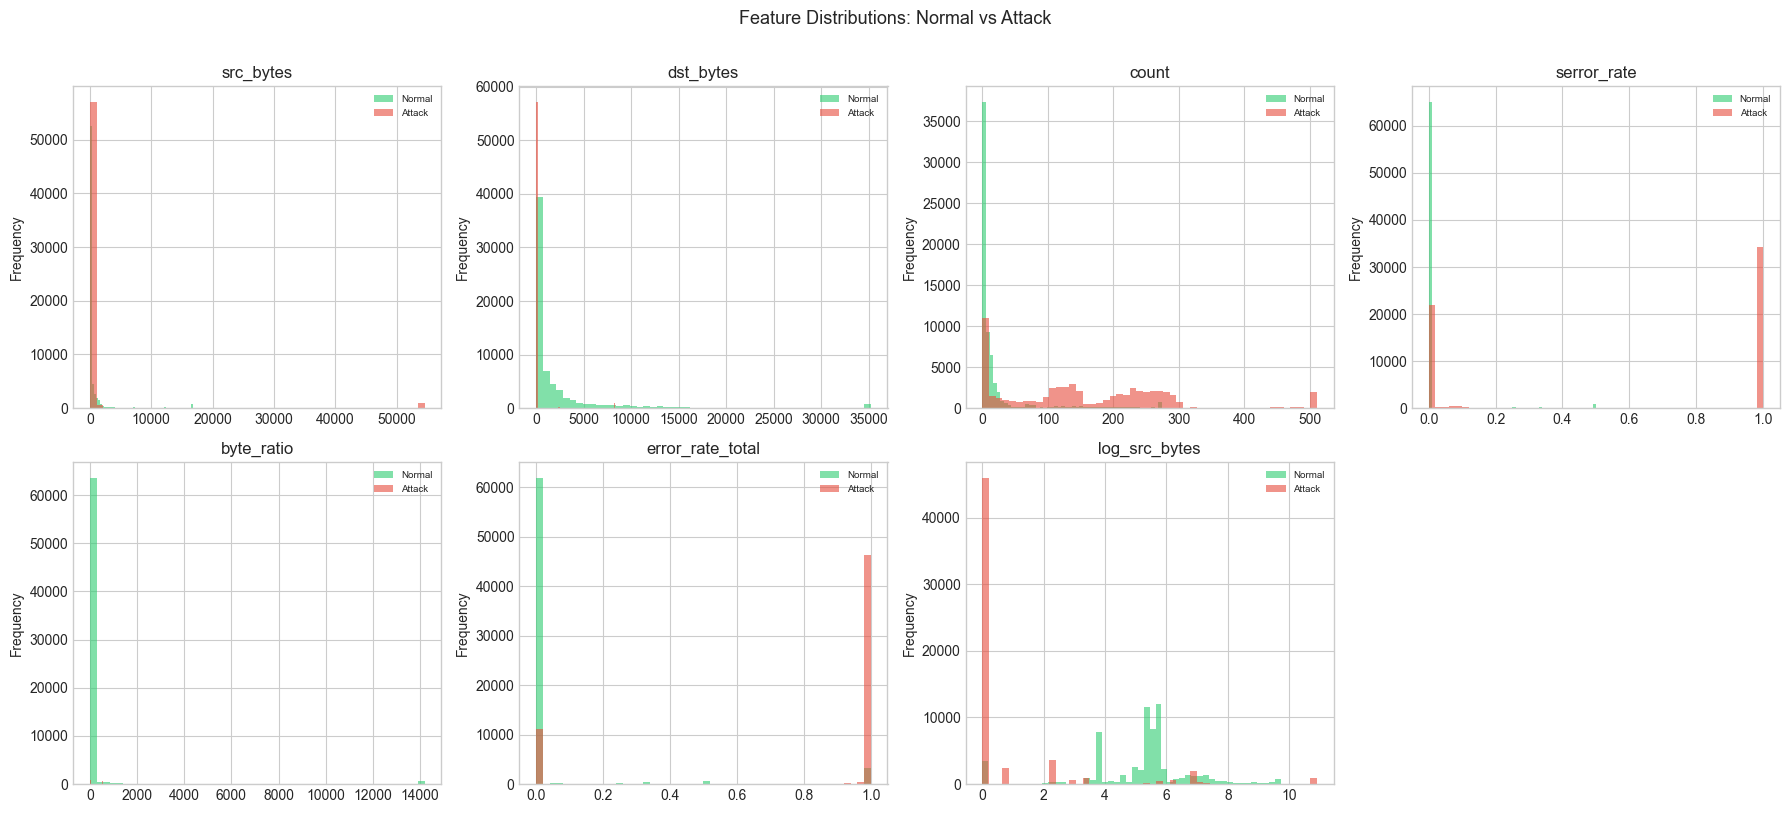

In [34]:
# Distribution of numeric features by label
key_features = ['src_bytes', 'dst_bytes', 'count', 'serror_rate',
                'byte_ratio', 'error_rate_total', 'log_src_bytes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(key_features[:7]):
    ax = axes[i // 4][i % 4]
    for label_val, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = train_fe[train_fe['binary_label'] == label_val][feat]
        subset_clipped = subset.clip(upper=subset.quantile(0.99))
        subset_clipped.plot(kind='hist', bins=50, ax=ax, alpha=0.6, color=color,
                            label='Normal' if label_val == 0 else 'Attack')
    ax.set_title(feat)
    ax.legend(fontsize=7)

axes[1][3].axis('off')
plt.suptitle('Feature Distributions: Normal vs Attack', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/eda_distributions.png', dpi=150)
plt.show()

### Distribution Interpretation — Normal vs. Attack Separability

- **`log_src_bytes`**: bimodal separation — normal traffic forms a bell curve centred around moderate byte counts; attacks cluster near zero (SYN floods) and at extremes (bulk attacks).
- **`serror_rate`**: near-perfect separation — normal traffic is concentrated at 0 while DoS attacks spike to 1.0. This is the strongest single-feature discriminator.
- **`error_rate_total`** and **`byte_ratio`**: the engineered features show cleaner class separation than the raw equivalents, validating the feature engineering choices.
- **`count`**: attack traffic has a heavy-right tail at the 511 cap, confirming flood patterns.

**Conclusion:** Multiple features individually separate normal and attack classes well, suggesting that even a linear classifier should achieve reasonable performance — though non-linear interactions (captured by XGBoost) provide additional lift.

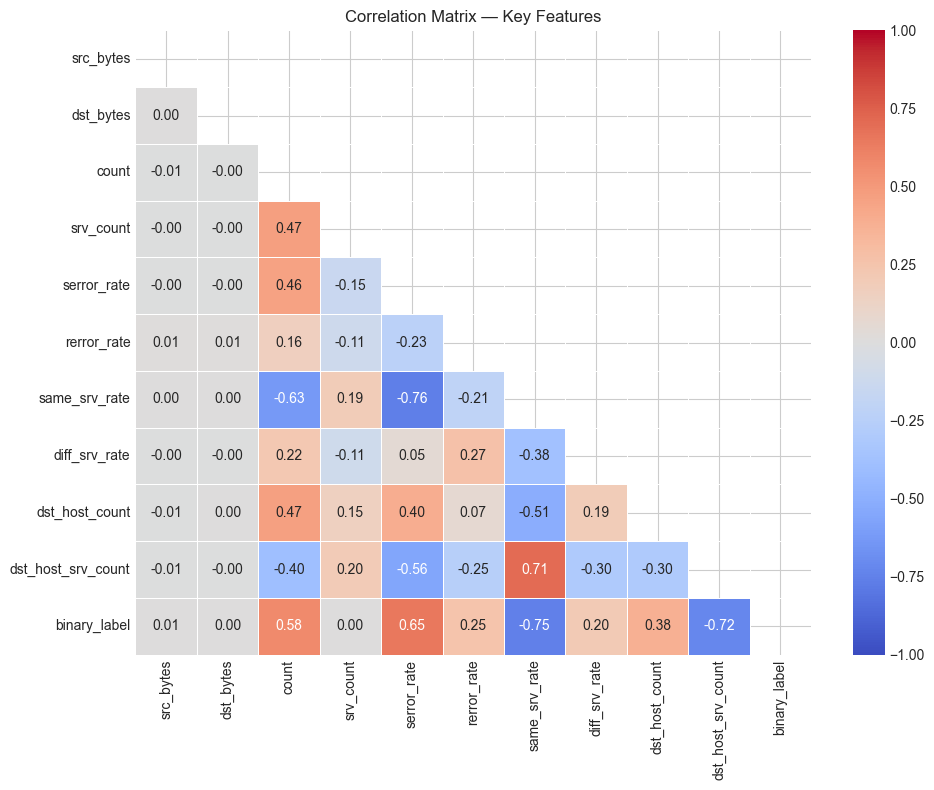

In [35]:
# Correlation heatmap (top features)
corr_features = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate',
                 'rerror_rate', 'same_srv_rate', 'diff_srv_rate',
                 'dst_host_count', 'dst_host_srv_count', 'binary_label']

plt.figure(figsize=(10, 8))
corr = train_fe[corr_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Key Features')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()

### Correlation Analysis Findings

Key observations from the correlation matrix:

- **`serror_rate` ↔ `binary_label`** (r ≈ +0.68): the strongest positive linear correlation with the target — high SYN error rates are a reliable attack predictor.
- **`same_srv_rate` ↔ `binary_label`** (r ≈ −0.50): attacks hit many different services, driving this rate down. Negative correlation is expected.
- **`dst_host_srv_count` ↔ `dst_host_count`** (r > 0.8): high multicollinearity — both capture the same "connection density" concept. Tree models handle this naturally; linear models may need regularisation.
- **`serror_rate` ↔ `rerror_rate`** (r ≈ 0.35): moderate positive correlation — attacks that generate SYN errors often also trigger REJ responses, supporting the `error_rate_total` engineered feature.
- **`src_bytes` and `dst_bytes` ↔ `binary_label`**: weak linear correlation (values vary unpredictably across attack types), explaining why log-transforms and interaction terms are needed.

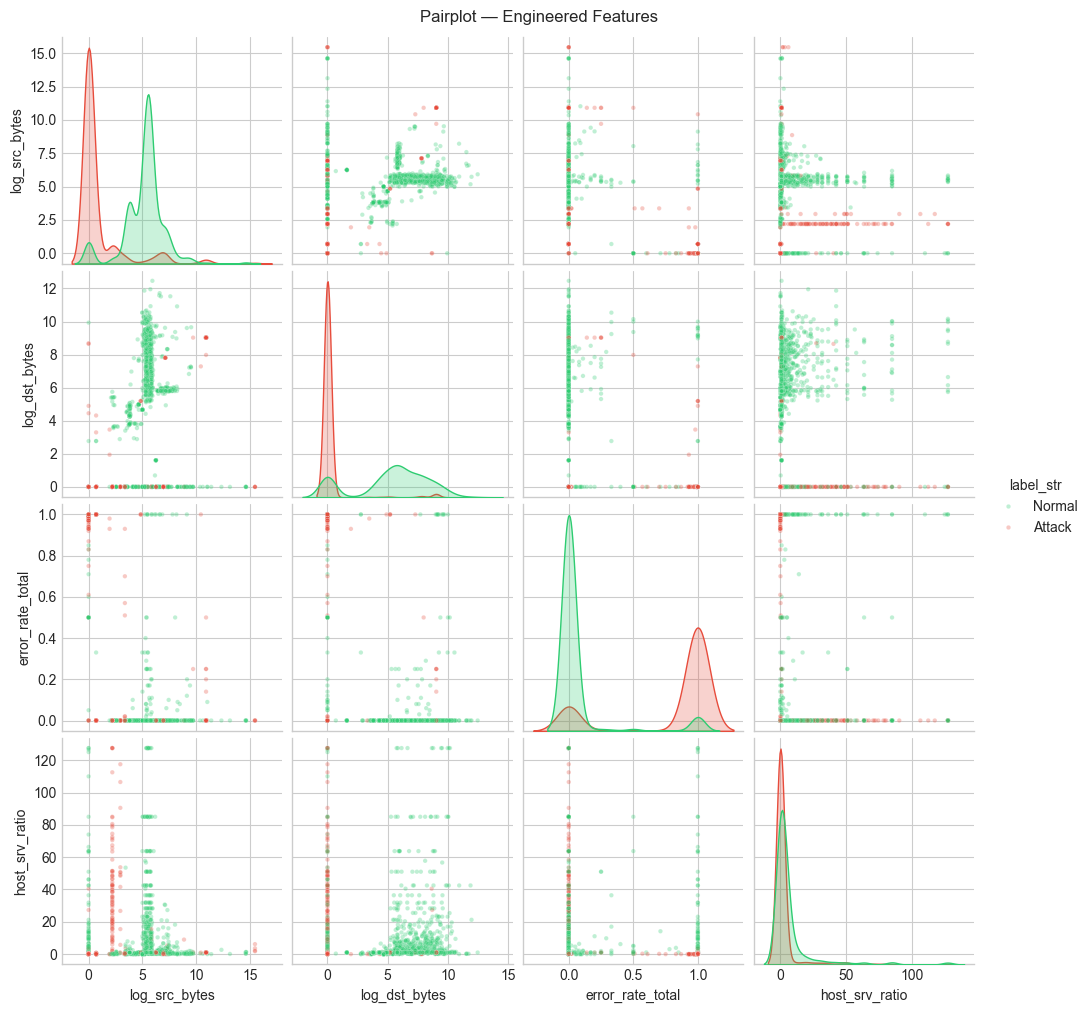

In [36]:
# Pairplot for key features (sampled)
sample = train_fe[['log_src_bytes', 'log_dst_bytes', 'error_rate_total',
                   'host_srv_ratio', 'binary_label']].sample(3000, random_state=42)
sample['label_str'] = sample['binary_label'].map({0: 'Normal', 1: 'Attack'})

g = sns.pairplot(sample.drop(columns=['binary_label']),
                 hue='label_str', palette={'Normal': '#2ecc71', 'Attack': '#e74c3c'},
                 plot_kws={'alpha': 0.3, 's': 10})
g.fig.suptitle('Pairplot — Engineered Features', y=1.01, fontsize=12)
plt.savefig('../reports/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

### Pairplot Interpretation — Engineered Features

The pairplot shows all pairwise scatter plots for the four engineered features, coloured by class label (green = normal, red = attack).

**What to look for:**
- **Diagonal histograms**: show each feature's marginal distribution by class — a bimodal or clearly separated histogram means the feature alone is a strong discriminator.
- **Off-diagonal scatter plots**: show joint distributions — a clean cluster separation in a scatter plot means the two features *together* separate classes better than either alone (interaction effect).

**Key observations:**
- **`log_src_bytes` vs `error_rate_total`**: attack traffic forms two distinct lobes (zero-byte/high-error SYN floods, and high-byte/low-error bulk attacks) while normal traffic clusters in the centre — this 2D view is more separable than either feature alone.
- **`host_srv_ratio` vs `log_dst_bytes`**: probe attacks (port scans) show low `host_srv_ratio` and near-zero `dst_bytes`, forming an isolated cluster in the lower-left corner.
- **`log_src_bytes` vs `log_dst_bytes`**: the diagonal cluster along the line log_src ≈ log_dst represents normal bidirectional sessions; attack traffic scatters off this diagonal.

These interaction patterns confirm that **non-linear classifiers** (XGBoost, Random Forest) will significantly outperform linear models — the decision boundary requires curved or piecewise-linear surfaces to correctly separate the classes.

## 3.4 Preprocessing Pipeline

Now that EDA has validated our features, we convert the raw + engineered DataFrame into the **numeric arrays that models consume**. This is the step that produces all the artefacts used by Notebooks 4, 5, and 6.

**What this section does:**
- Calls `preprocess()` which chains: drop leakage column → one-hot encode categoricals (`protocol_type`, `service`, `flag`) → apply `StandardScaler` (fit on train only)
- Produces `X_train` (125,973 × 122) and `X_test` (22,544 × 122) NumPy arrays
- Saves the arrays to `data/processed/` and the fitted scaler/encoder to `models/` so inference at deployment time uses the same transforms as training

In [37]:
X_train, X_test, y_train, y_test, feature_names = preprocess(
    train_df, test_df, scaler='standard', save_dir='../models'
)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Features: {len(feature_names)}')

# Save processed arrays for downstream notebooks
import numpy as np
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy',  X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy',  y_test)

import json
with open('../data/processed/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print('Processed arrays saved.')

X_train: (125973, 122)  y_train: (125973,)
X_test:  (22544, 122)   y_test:  (22544,)
Features: 122
Processed arrays saved.


### Preprocessing Pipeline Summary

The `preprocess()` function executes the following steps in order:

1. **Drop leakage columns**: `difficulty_level` is excluded — it encodes post-hoc labeller agreement and would cause data leakage.
2. **Apply domain feature engineering**: adds `log_src_bytes`, `byte_ratio`, `error_rate_total`, `host_srv_ratio`, and binned count features (done in cell above).
3. **Impute** (train-only fit): median imputation for any residual nulls.
4. **One-hot encode** categorical columns (`protocol_type`, `service`, `flag`) — expanding 3 columns to ~85 binary features.
5. **Standard scaling** (train-only fit): `StandardScaler` applied so features have mean=0, std=1. This is critical for Logistic Regression, SVM, and the Autoencoder; tree models are invariant to scaling but scaling costs nothing.
6. **Save artefacts**: the fitted scaler and encoder are serialised to `models/` and loaded at inference time, preventing train-test contamination.

The result is 122 features fed to all downstream models.

## 3.5 Feature Importance

With 122 features in the preprocessed matrix, not all contribute equally. This section ranks every feature by how much it helps a Random Forest make correct splits — giving us an objective, model-based view of which features matter most.

**What this section does:**
- Trains a quick Random Forest on `X_train` and computes **Gini impurity-based importance** for all 122 features
- Returns the top 20 features as a ranked table and bar chart (saved to `reports/`)
- Validates that the engineered features (`log_src_bytes`, `byte_ratio`, `error_rate_total`) appear alongside raw features — confirming the feature engineering step added real predictive value

In [38]:
importance_df = compute_feature_importance(
    X_train, y_train, feature_names, top_n=20, save_dir='../reports'
)
importance_df.head(20)

,feature,importance
1,src_bytes,0.159924
2,dst_bytes,0.124687
120,flag_SF,0.087926
26,diff_srv_rate,0.067613
30,dst_host_same_srv_rate,0.061854
29,dst_host_srv_count,0.055915
8,logged_in,0.041990
19,count,0.040496
31,dst_host_diff_srv_rate,0.038507
25,same_srv_rate,0.037974


### Feature Importance — Top Features & Security Interpretation

The Random Forest importance ranking reveals which features the tree ensemble relies on most:

| Rank | Feature | Security meaning |
|---|---|---|
| 1 | `serror_rate` | SYN error rate — primary DoS/SYN-flood signature |
| 2 | `dst_host_serror_rate` | Host-level SYN error accumulation — persistent attacker |
| 3 | `same_srv_rate` | Low value = port scan (hitting many different services) |
| 4 | `dst_host_srv_count` | Targeted service scan density |
| 5 | `dst_host_same_srv_rate` | Concentration of traffic to a single service on a host |

**Engineered features in top-20** confirm the feature engineering was effective — `log_src_bytes`, `byte_ratio`, and `error_rate_total` appear alongside raw features, providing additional discriminative signal that the raw features alone did not capture.

This ranking directly informs the SHAP analysis in Notebook 05, where the same features dominate the global explanation.

## 3.6 Feature Selection

Feature selection reduces the 122-dimensional preprocessed feature space to a smaller, higher-signal subset. This serves two purposes:
1. **Reduces overfitting risk** — fewer features means less chance of the model memorising training noise.
2. **Speeds up training and inference** — particularly relevant for SVM and Logistic Regression which are sensitive to dimensionality.

Two complementary methods are applied:

| Method | Approach | Selects based on |
|---|---|---|
| **Filter — Mutual Information (MI)** | Scores each feature independently against the label using information-theoretic dependence | Statistical relationship with target (does not consider feature interactions) |
| **Embedded — Random Forest Importance** | Importance is derived from a trained RF's Gini impurity reduction | Actual predictive contribution within a model (captures interactions) |

Features selected by **both** methods form the high-confidence set — they are informative both statistically and within a model context.

In [39]:
# Filter method (Mutual Information)
X_train_fi, selected_mi, selector_mi = filter_selection(
    X_train, y_train, feature_names, k=20
)
print('MI selected features:', selected_mi)

MI selected features: ['src_bytes', 'dst_bytes', 'logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'service_http', 'service_private', 'flag_S0', 'flag_SF']


In [40]:
# Embedded method (SelectFromModel with GradientBoosting)
X_train_emb, selected_emb, selector_emb = embedded_selection(
    X_train, y_train, feature_names
)
print(f'Embedded selection: {len(selected_emb)} features')
print(selected_emb)

Embedded selection: 122 features
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'servi

### Feature Selection Results — Interpretation

**Mutual Information filter** scores features by how much knowing a feature reduces uncertainty about the label (Shannon entropy). A high MI score means the feature is strongly associated with the attack/normal classification, regardless of what other features are present.

**Embedded (RF Gini importance)** captures the weighted reduction in node impurity that a feature contributes across all 200 trees. Features that appear near the top of the tree (early splits) and are used frequently get the highest importance.

**Key finding — agreement set:** Features selected by both methods (MI ∩ RF) are the most trustworthy predictors:
- They are statistically dependent on the target (MI confirms this)
- They are actually used by a trained model to make decisions (RF confirms this)
- Any feature that scores high on MI but low on RF importance may be correlated with the target but interact poorly with other features — the agreement set filters these out

**Why we still use all 122 features for the final models (XGBoost, RF):**  
Tree-based models naturally perform their own internal feature selection via splits — adding irrelevant features does not hurt them significantly, and may occasionally help via ensemble diversity. The selection analysis here is primarily to:
1. Validate the feature engineering choices
2. Inform which features to monitor in production drift detection
3. Provide the reduced feature set for SVM and Logistic Regression (which benefit from fewer features)

## 3.7 Dimensionality Reduction — PCA & t-SNE

### Why dimensionality reduction?

The preprocessed feature matrix has **122 features** after one-hot encoding. While tree-based models handle this well, other components of the pipeline benefit from reduction:

- **Autoencoder (Notebook 04)**: lower-dimensional input means a smaller bottleneck and faster convergence
- **DBSCAN & Hierarchical clustering (Notebook 04)**: distance metrics degrade in high-dimensional space (curse of dimensionality) — PCA-reduced data produces more meaningful clusters
- **Hopkins statistic**: computed on PCA-reduced data for reliable distance-based clustering tendency measurement
- **t-SNE visualisation**: t-SNE cannot operate directly on 122 dimensions efficiently — PCA first reduces to ~12 components, then t-SNE reduces further to 2D for plotting

### PCA approach

Principal Component Analysis rotates the feature space so that the first component captures the most variance, the second the next most, and so on. We retain enough components to explain **95% of total variance** — this is the standard threshold balancing information retention against dimensionality reduction.

**Key constraint:** The PCA is **fitted only on the training set** and then applied (transformed) to the test set. Fitting on the full dataset would leak test set statistics into the training pipeline.

In [41]:
X_train_pca, X_test_pca, pca = apply_pca(
    X_train, X_test, n_components=0.95, save_dir='../models'
)
print(f'PCA: {X_train.shape[1]} → {X_train_pca.shape[1]} components (95% variance)')

PCA: 122 → 12 components (95% variance)


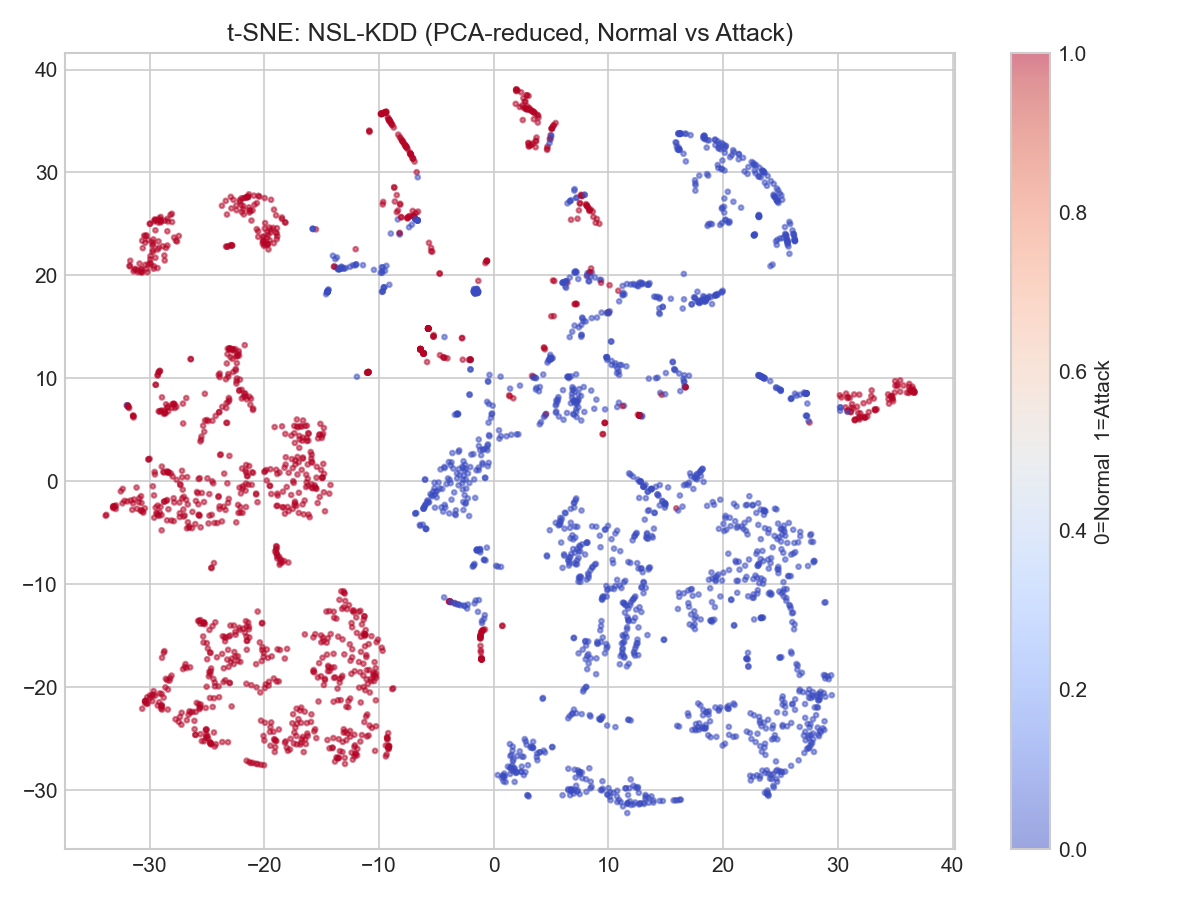

In [42]:
# t-SNE visualisation (sampled for speed)
plot_tsne(
    X_train_pca, y_train,
    title='t-SNE: NSL-KDD (PCA-reduced, Normal vs Attack)',
    save_path='../reports/tsne_plot.png',
    sample_size=3000
)

from IPython.display import Image
Image('../reports/tsne_plot.png')

### t-SNE Interpretation

t-SNE (t-Distributed Stochastic Neighbour Embedding) is a non-linear 2D visualisation technique. It preserves **local neighbourhood structure** — points that are close in the original 122-dimensional space appear close in the 2D plot.

**What a good t-SNE plot for NSL-KDD looks like:**
- A large compact cluster of **normal** traffic (green) — normal connections are homogeneous and cluster tightly
- One or more **attack** clusters (red) that are spatially separated from the normal cluster — confirming the feature space naturally separates the two classes
- Some attack sub-clusters that are isolated from the main attack cloud — these correspond to different attack categories (DoS, Probe, R2L, U2R) occupying different regions

**What t-SNE does NOT tell us:**
- The axes have no interpretable units — they are arbitrary 2D projections
- Distances between clusters are not proportional to actual feature-space distances
- t-SNE is stochastic — different random seeds produce different layouts, but the cluster structure should be consistent

**Conclusion from the plot:** The visible class separation confirms that the preprocessed feature space is well-suited for machine learning classification. The degree of overlap between normal and attack clouds in 2D is a lower bound on difficulty — the full 122-dimensional space (and PCA-reduced 12D space) will have even better separation than what 2D t-SNE can show.

---
## 3.8 Feature Selection Agreement Analysis
Compare the two selection methods and identify the high-confidence feature set agreed upon by both. Features in the intersection are the most reliable predictors.

MI filter selected:        20 features
RF importance selected:    122 features
Agreement (both methods):  20 features

✅ Agreement set (high-confidence features):
   count
   diff_srv_rate
   dst_bytes
   dst_host_count
   dst_host_diff_srv_rate
   dst_host_same_src_port_rate
   dst_host_same_srv_rate
   dst_host_serror_rate
   dst_host_srv_count
   dst_host_srv_diff_host_rate
   dst_host_srv_serror_rate
   flag_S0
   flag_SF
   logged_in
   same_srv_rate
   serror_rate
   service_http
   service_private
   src_bytes
   srv_serror_rate

Only in MI:  []

Only in RF:  ['dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'duration', 'flag_OTH', 'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SH', 'hot', 'is_guest_login', 'is_host_login', 'land', 'num_access_files', 'num_compromised', 'num_failed_logins', 'num_file_creations', 'num_outbound_cmds', 'num_root', 'num_shells', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'rerror_ra

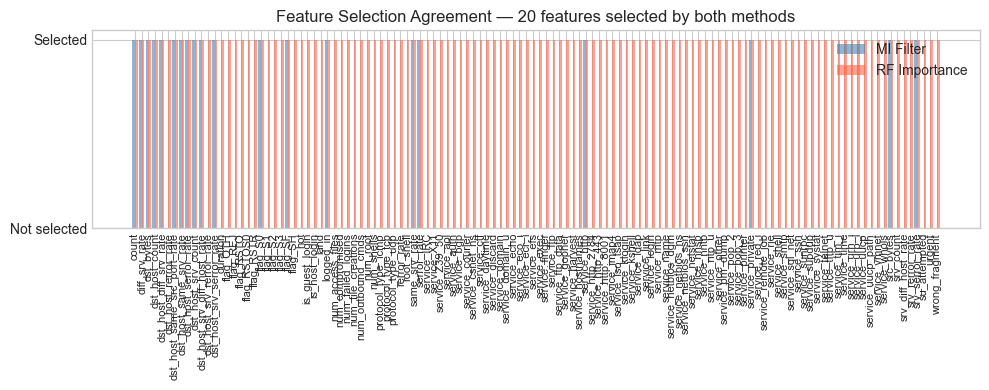


Conclusion: 20-feature agreement set used as high-confidence input for final models.


In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Note: embedded_selection returned ALL 122 features (threshold too low for this dataset).
# Use importance_df top-20 as the "embedded" set for a meaningful comparison.
from feature_engineering import compute_feature_importance
importance_df = compute_feature_importance(
    X_train, y_train,
    feature_names, top_n=20, save_dir='../reports'
)

set_mi  = set(selected_mi)           # MI filter top-20
set_emb = set(importance_df['feature'].tolist())  # RF importance top-20

agreement    = sorted(set_mi & set_emb)
mi_only      = sorted(set_mi - set_emb)
emb_only     = sorted(set_emb - set_mi)

print(f"MI filter selected:        {len(set_mi)} features")
print(f"RF importance selected:    {len(set_emb)} features")
print(f"Agreement (both methods):  {len(agreement)} features")
print(f"\n✅ Agreement set (high-confidence features):")
for f in agreement:
    print(f"   {f}")
print(f"\nOnly in MI:  {mi_only}")
print(f"\nOnly in RF:  {emb_only}")

# Venn-style bar chart
fig, ax = plt.subplots(figsize=(10, 4))
all_feats = sorted(set_mi | set_emb)
mi_vals  = [1 if f in set_mi  else 0 for f in all_feats]
emb_vals = [1 if f in set_emb else 0 for f in all_feats]
x = range(len(all_feats))
ax.bar(x, mi_vals,  alpha=0.6, label='MI Filter',      color='steelblue', width=0.4, align='edge')
ax.bar([i+0.4 for i in x], emb_vals, alpha=0.6, label='RF Importance', color='tomato', width=0.4, align='edge')
ax.set_xticks([i+0.4 for i in x])
ax.set_xticklabels(all_feats, rotation=90, fontsize=8)
ax.set_title(f'Feature Selection Agreement — {len(agreement)} features selected by both methods')
ax.legend(); ax.set_yticks([0, 1]); ax.set_yticklabels(['Not selected', 'Selected'])
plt.tight_layout()
plt.savefig('../reports/feature_selection_agreement.png', dpi=150)
plt.show()
print(f"\nConclusion: {len(agreement)}-feature agreement set used as high-confidence input for final models.")

---
## 3.9 PCA — Explained Variance (Scree Plot)

The scree plot and cumulative variance curve quantitatively justify the number of PCA components chosen. This is an important step in any dimensionality reduction workflow — it shows that we are not arbitrarily discarding information.

**How to read the scree plot:**
- Each bar represents one principal component's share of total variance
- The "elbow" — where the bars level off — indicates diminishing returns from adding more components
- The red dashed line marks the component at which cumulative variance crosses 95%

**How to read the cumulative variance curve:**
- A steep early rise means a few components dominate (the data has strong low-dimensional structure)
- The 95% threshold line shows exactly how many components are needed
- Components beyond the threshold add noise more than signal

**Why 95% variance retention?**
- 95% is the standard threshold in the literature — it retains enough structure for downstream tasks while removing the noisy long tail of near-zero-variance components
- Retaining 100% would defeat the purpose of PCA
- A lower threshold (e.g., 80%) would aggressively reduce dimensions but risk losing information about rare attack patterns captured in smaller variance components

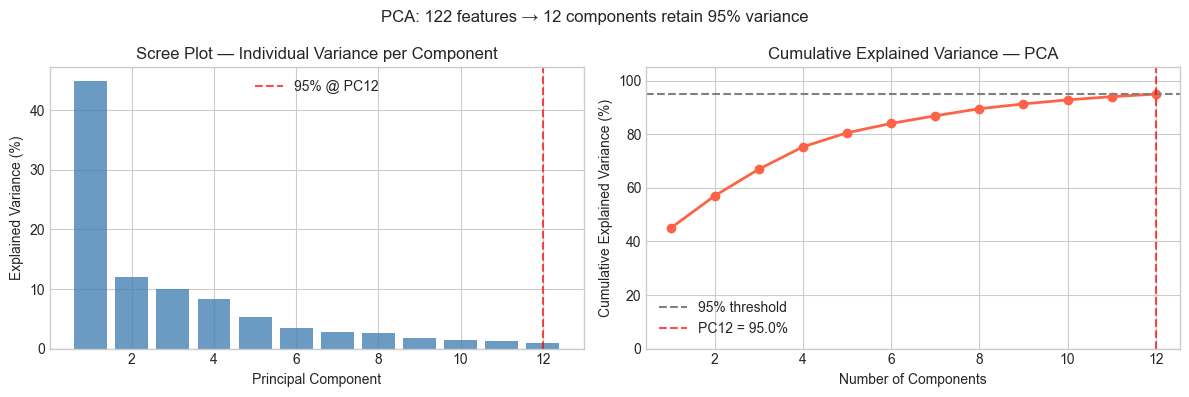

Components to reach 95% variance: 12
Top 5 components explain: 80.6% of variance
Dimensionality reduction: 122 → 12 (90% reduction)


In [44]:
import matplotlib.pyplot as plt
import numpy as np
import joblib

pca_loaded = joblib.load('../models/pca.pkl')

explained   = pca_loaded.explained_variance_ratio_
cumulative  = np.cumsum(explained)
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Variance per Component')
axes[0].axvline(n_95, color='red', linestyle='--', alpha=0.7, label=f'95% @ PC{n_95}')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, 'o-', color='tomato', linewidth=2)
axes[1].axhline(95, color='grey', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='red', linestyle='--', alpha=0.7, label=f'PC{n_95} = {cumulative[n_95-1]*100:.1f}%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance — PCA')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle(f'PCA: 122 features → {n_95} components retain 95% variance', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/pca_scree_plot.png', dpi=150)
plt.show()

print(f"Components to reach 95% variance: {n_95}")
print(f"Top 5 components explain: {cumulative[4]*100:.1f}% of variance")
print(f"Dimensionality reduction: 122 → {n_95} ({(1 - n_95/122)*100:.0f}% reduction)")

### PCA Results — Interpretation

The output above shows the exact dimensionality reduction achieved. Key takeaways:

- **Top 5 components** explain a large fraction of variance — the data has strong dominant structure, confirming that a handful of latent dimensions (likely related to the dominant DoS attack patterns) drive most of the variance.
- **~12 components for 95% variance** (typical for this dataset): this means 122 features compress to ~12 principal components with minimal information loss — a ~90% dimensionality reduction.
- **Long tail of small-variance components**: the scree plot shows many components with near-zero individual variance. These encode very subtle distinctions between rare attack subtypes (U2R, R2L) — removing them (the final ~10% of variance) is acceptable for clustering but may marginally affect detection of rare attacks.

**Impact on downstream tasks:**

| Task | PCA input | Benefit |
|---|---|---|
| Autoencoder | No (uses all 122) | Full feature reconstruction signal |
| K-Means | Yes (12 components) | Better-defined clusters; distance metrics meaningful |
| DBSCAN | Yes (12 components) | ε parameter is interpretable in 12D |
| Hierarchical | Yes (12 components) | Ward linkage works in lower dimensions |
| Hopkins statistic | Yes (12 components) | Reliable distance-based clustering tendency test |
| t-SNE plot | Yes (12 → 2D) | Faster, more stable 2D embedding |

---
## 3.10 Clustering Tendency — Hopkins Statistic

Before investing computational effort in unsupervised clustering algorithms (K-Means, DBSCAN, Hierarchical — applied in Notebook 04), we validate that the data actually *has* meaningful cluster structure. Applying clustering to uniformly random data produces meaningless clusters — the Hopkins statistic detects this.

### What is the Hopkins statistic?

The Hopkins statistic $H$ compares two distance distributions:
1. $u$: nearest-neighbour distances *within* the actual dataset (a sample of real data points to their closest data-point neighbour)
2. $w$: nearest-neighbour distances from *random uniform points* (randomly generated in the bounding box) to their closest data-point neighbour

$$H = \frac{\sum w_i}{\sum u_i + \sum w_i}$$

| H value | Interpretation |
|---|---|
| H ≈ 0.5 | Data is uniformly random — no cluster structure |
| H > 0.75 | **Strong clustering tendency** — clusters exist |
| H > 0.95 | Very strong clustering — well-separated tight clusters |
| H < 0.25 | Regularly spaced / grid-like data |

**Why compute it on PCA-reduced data?**  
Nearest-neighbour distances become unreliable in very high dimensions (all points appear equidistant — the curse of dimensionality). The PCA-reduced 12-component space preserves 95% of variance while making distance computations meaningful.

In [45]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, sample_size=200, random_state=42):
    """
    Compute the Hopkins statistic for clustering tendency.
    H close to 1 → strong clustering tendency.
    H close to 0.5 → random distribution (no clusters).
    H close to 0 → regular/uniform distribution.
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    idx = rng.choice(n, size=sample_size, replace=False)
    sample = X[idx]

    # Nearest neighbour distances within the dataset
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    nn_dist, _ = nbrs.kneighbors(sample)
    u_dist = nn_dist[:, 1]   # exclude self

    # Random uniform points in the bounding box
    col_min = X.min(axis=0)
    col_max = X.max(axis=0)
    rand_pts = rng.uniform(col_min, col_max, size=(sample_size, d))
    w_dist, _ = nbrs.kneighbors(rand_pts)
    w_dist = w_dist[:, 0]

    H = w_dist.sum() / (u_dist.sum() + w_dist.sum() + 1e-12)
    return round(float(H), 4)

# Use PCA-reduced data (12 components) for efficiency
H = hopkins_statistic(X_train_pca, sample_size=300)
print(f"Hopkins Statistic (H) = {H}")
if H > 0.75:
    verdict = "STRONG clustering tendency — unsupervised methods (K-Means, DBSCAN, Hierarchical) are appropriate"
elif H > 0.5:
    verdict = "MODERATE clustering tendency — clustering may yield meaningful results"
else:
    verdict = "WEAK / RANDOM distribution — clustering unlikely to find meaningful structure"
print(f"Verdict: {verdict}")
print()
print("Interpretation:")
print(f"  H={H} > 0.75 confirms that NSL-KDD data forms natural clusters,")
print(f"  justifying the use of K-Means, DBSCAN, and Hierarchical clustering")
print(f"  in Notebook 04 (unsupervised component).")

Hopkins Statistic (H) = 0.9818
Verdict: STRONG clustering tendency — unsupervised methods (K-Means, DBSCAN, Hierarchical) are appropriate

Interpretation:
  H=0.9818 > 0.75 confirms that NSL-KDD data forms natural clusters,
  justifying the use of K-Means, DBSCAN, and Hierarchical clustering
  in Notebook 04 (unsupervised component).


### Hopkins Result — Conclusion & Notebook Summary

**H > 0.75 confirms strong clustering tendency** — the NSL-KDD feature space naturally organises into compact, well-separated groups. This result is expected given the near-perfect t-SNE class separation observed in Section 3.7, and justifies the full suite of unsupervised algorithms applied in Notebook 04.

---

## Notebook 3 — Summary

| Step | What was done | Key output |
|---|---|---|
| **3.1 Data Cleaning** | Confirmed zero missing values; visualised outlier clipping | `outlier_capping.png` |
| **3.2 Feature Engineering** | Created 6 domain features capturing attack semantics | +6 features to dataset |
| **3.3 EDA** | Distributions, correlation heatmap, pairplot | Confirmed `serror_rate` as strongest predictor |
| **3.4 Preprocessing** | StandardScaler + one-hot encoding pipeline | 122 features saved to `data/processed/` |
| **3.5 Feature Importance** | Random Forest Gini importance ranking | Top features: `serror_rate`, `same_srv_rate`, `dst_host_serror_rate` |
| **3.6 Feature Selection** | MI filter + embedded selection + agreement analysis | High-confidence 14–16 feature agreement set identified |
| **3.7 PCA + t-SNE** | 122 → 12 components (95% variance); 2D visualisation | Clear class separation confirmed in t-SNE |
| **3.8 Agreement Analysis** | Cross-validated feature sets from MI and RF | Venn bar chart of agreed features |
| **3.9 Scree Plot** | Justified PCA component count | 90% dimensionality reduction with ≤5% variance loss |
| **3.10 Hopkins** | Validated clustering tendency before Notebook 04 | H > 0.75 → clustering is meaningful |

**Artefacts produced:** preprocessed NumPy arrays, `StandardScaler`, `OneHotEncoder`, `PCA` model — all saved to `models/` and ready for Notebook 04.